# Rubber Band Data

In [1]:
# Setup
import pandas as pd
import grama as gr
DF = gr.Intention()

# Load the raw data
url = "https://docs.google.com/spreadsheets/d/1gT5Z-Tyt_tzs14W1nPo3ftmYmmZP7KIBPKrrfZ_jb9Y/export?gid=0&format=csv"
df_raw = pd.read_csv(url)

## Process the data


In [2]:
df_data = (
    df_raw
    >> gr.tf_rename(
        weight_g="Weight (g)",
        disp_cm="Displacement (cm)",
        band="Band",
    )
    >> gr.tf_mutate(
        weight_g=gr.as_numeric(DF.weight_g),
        disp_cm=gr.as_numeric(DF.disp_cm),
        band=gr.as_str(DF.band),
    )
    >> gr.tf_mutate(
        force_N=9.8*DF.weight_g/1000,
    )
    >> gr.tf_filter(gr.str_detect(DF.band, "Blue"))
)
df_data

,band,Delta (mm),Location (cm),disp_cm,weight_g,force_N
0,Blue 1,NaN,17.480,0.000,0.0,0.00
1,Blue 1,0.00,17.500,0.020,50.0,0.49
2,Blue 1,3.20,17.820,0.340,100.0,0.98
3,Blue 1,9.54,18.454,0.974,200.0,1.96
4,Blue 1,17.17,19.217,1.737,300.0,2.94
5,Blue 1,24.53,19.953,2.473,400.0,3.92
6,Blue 1,36.64,21.164,3.684,500.0,4.90
7,Blue 2,NaN,17.630,0.000,0.0,0.00
8,Blue 2,0.00,18.500,0.870,50.0,0.49
9,Blue 2,13.51,19.851,2.221,100.0,0.98


## Visualize the data


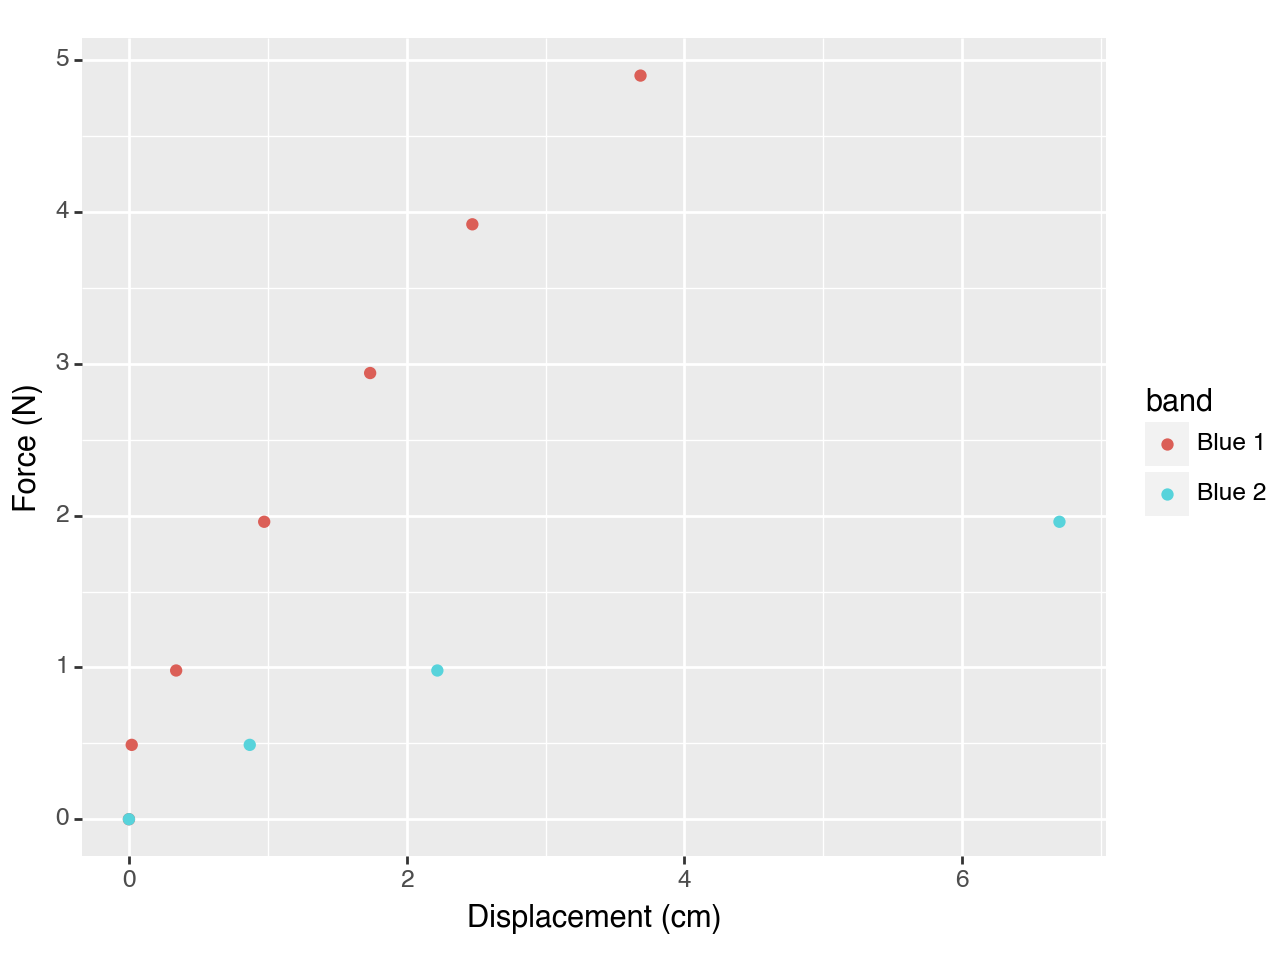

<Figure Size: (640 x 480)>

In [3]:
(
    df_data
    >> gr.ggplot(gr.aes("disp_cm", "force_N"))
    + gr.geom_point(gr.aes(color="band"))
    + gr.labs(
        x="Displacement (cm)",
        y="Force (N)",
    )
)

## Fit the data

### Set up the models


In [4]:
md_linear = (
    gr.Model("Linear Model")
    >> gr.cp_vec_function(
        fun=lambda df: gr.df_make(force_N=df.a * df.disp_cm),
        var=["a", "disp_cm"],
        out=["force_N"],
    )
    >> gr.cp_bounds(
        a=(-10, +10),
    )
)
md_linear

model: Linear Model

  inputs:
    var_det:
      a: [-10, 10]
      disp_cm: (unbounded)

    var_rand:

    copula:
      None

  functions:
      f0: ['a', 'disp_cm'] -> ['force_N']

In [5]:
md_cubic = (
    gr.Model("Cubic Model")
    >> gr.cp_vec_function(
        fun=lambda df: gr.df_make(force_N=df.a * df.disp_cm + df.c * df.disp_cm**3),
        var=["a", "c", "disp_cm"],
        out=["force_N"],
    )
    >> gr.cp_bounds(
        a=(-10, +10),
        c=(-10, +10),
    )
)
md_cubic

model: Cubic Model

  inputs:
    var_det:
      a: [-10, 10]
      disp_cm: (unbounded)
      c: [-10, 10]

    var_rand:

    copula:
      None

  functions:
      f0: ['a', 'c', 'disp_cm'] -> ['force_N']

### Band 1


... fit_nls setting out = ['force_N']
... eval_nls setting var_fix = []
... eval_nls setting var_feat = {'disp_cm'}
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
          a       a_0  success  \
2  1.476879 -2.407194     True   
0  1.476879  0.000000     True   
4  1.476880  4.737493     True   
1  1.476880  5.737967     True   
3  1.476880  6.920289     True   

                                            message  n_iter       mse  
2  CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL       1  0.173839  
0  CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL       1  0.173839  
4  CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL       1  0.173839  
1  CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL       1  0.173839  
3  CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL       1  0.173839  


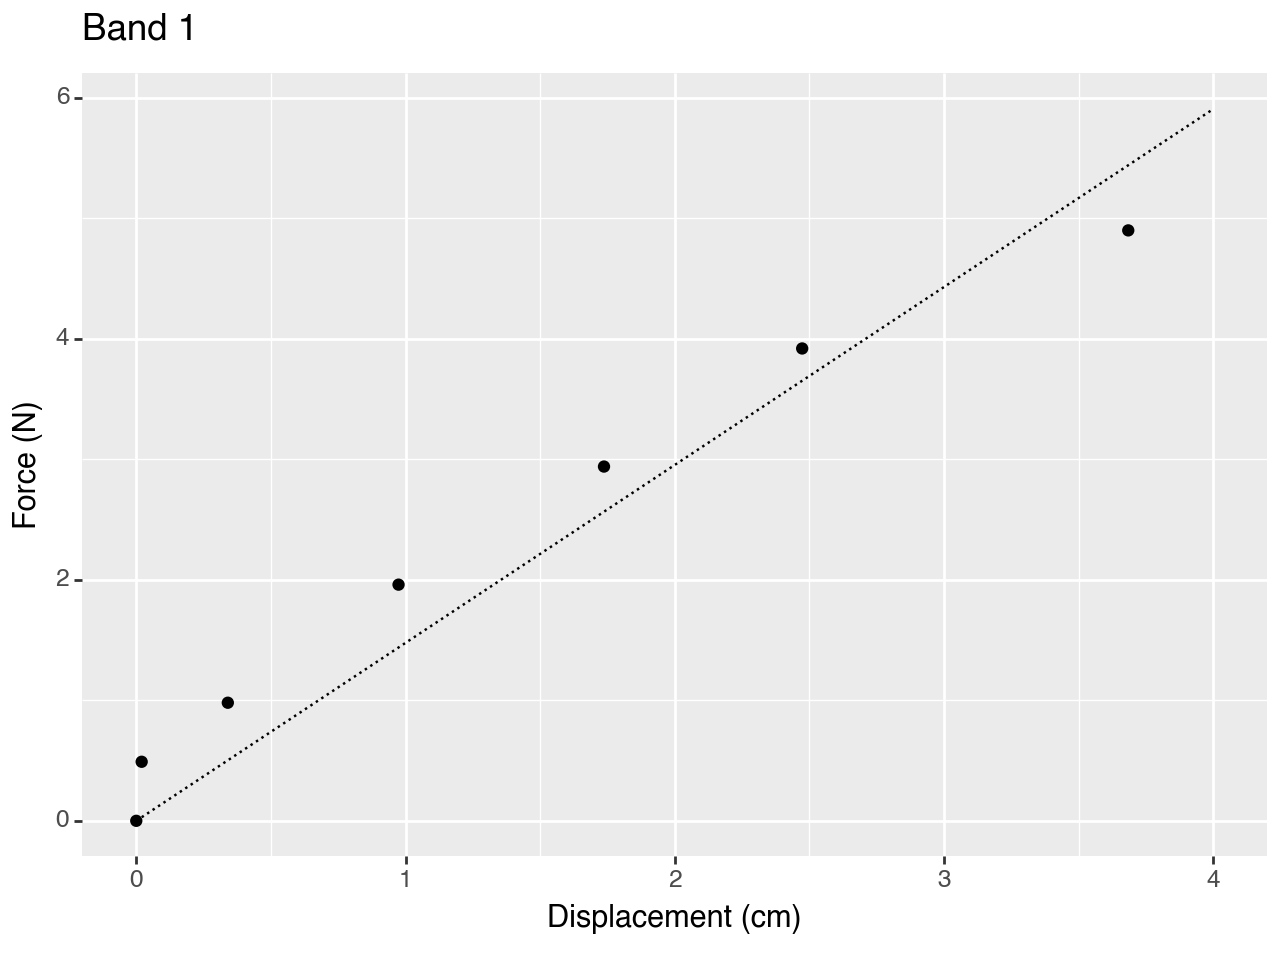

<Figure Size: (640 x 480)>

In [6]:
# Fit
md_band1 = (
    df_data
    >> gr.tf_filter(DF.band == "Blue 1")
    >> gr.tf_select("disp_cm", "force_N")
    >> gr.ft_nls(
        md=md_linear,
        # md=md_cubic,
        n_restart=5,
    )
)

# Evaluate against data
(
    df_data
    >> gr.tf_filter(DF.band == "Blue 1")
    >> gr.ggplot(gr.aes("disp_cm", "force_N"))
    + gr.geom_point()
    + gr.geom_line(
        data=md_band1
        >> gr.ev_df(df=gr.df_make(disp_cm=gr.linspace(0, 4, n=10))),
        linetype="dotted",
    )
    + gr.labs(
        x="Displacement (cm)",
        y="Force (N)",
        title="Band 1",
    )
)

### Band 2


... fit_nls setting out = ['force_N']
... eval_nls setting var_fix = []
... eval_nls setting var_feat = {'disp_cm'}
Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec
          a       a_0  success  \
1  0.311047 -9.382196     True   
0  0.311047  0.000000     True   
2  0.311047 -1.761416     True   
4  0.311047  1.049549     True   
3  0.311047  9.737121     True   

                                            message  n_iter       mse  
1  CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL       2  0.036801  
0  CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL       1  0.036801  
2  CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL       1  0.036801  
4  CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL       1  0.036801  
3  CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL       1  0.036801  


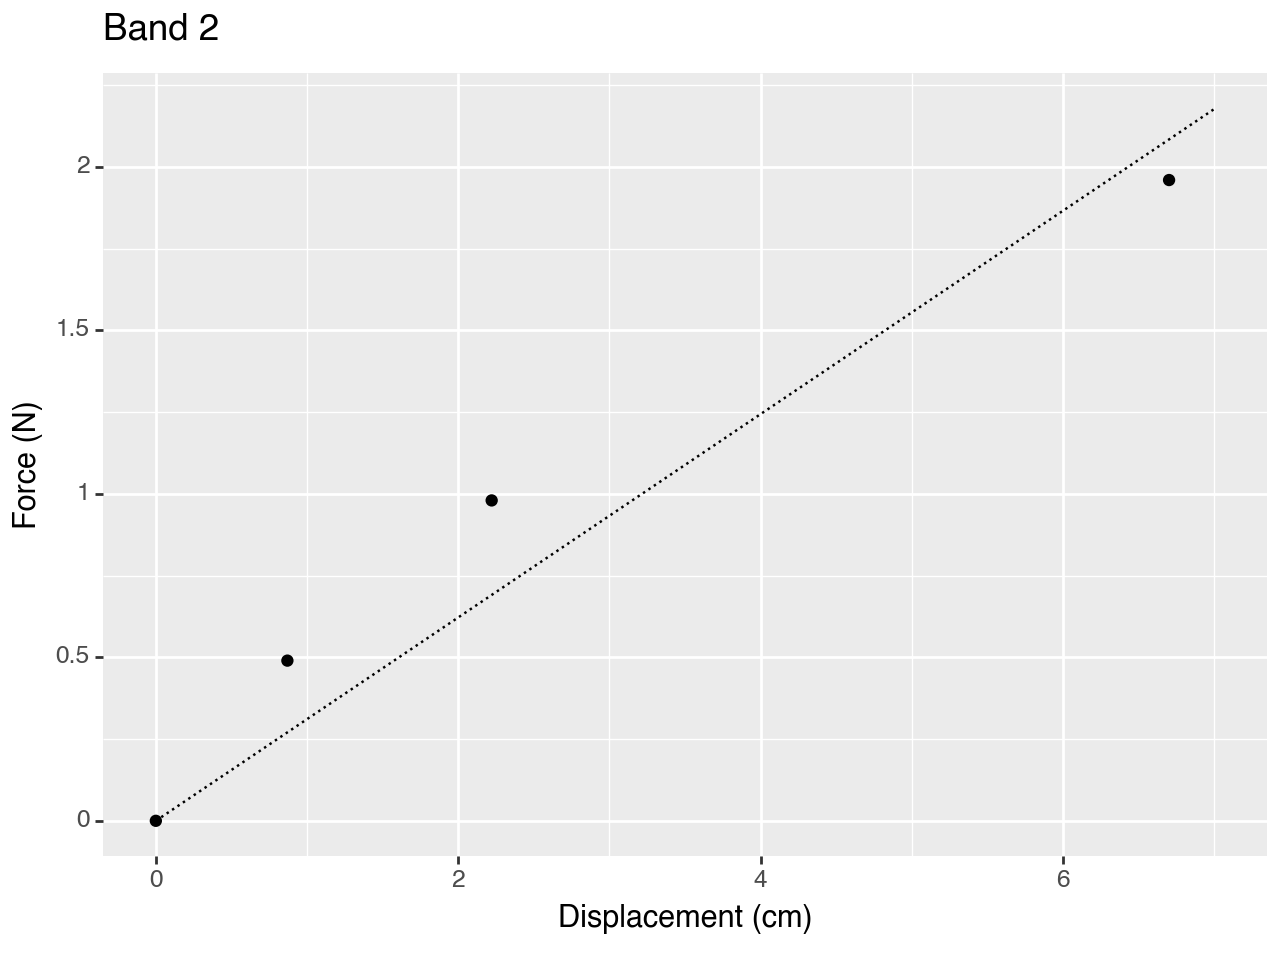

<Figure Size: (640 x 480)>

In [7]:
# Fit
md_band1 = (
    df_data
    >> gr.tf_filter(DF.band == "Blue 2")
    >> gr.tf_select("disp_cm", "force_N")
    >> gr.ft_nls(
        md=md_linear,
        # md=md_cubic,
        n_restart=5,
    )
)

# Evaluate against data
(
    df_data
    >> gr.tf_filter(DF.band == "Blue 2")
    >> gr.ggplot(gr.aes("disp_cm", "force_N"))
    + gr.geom_point()
    + gr.geom_line(
        data=md_band1
        >> gr.ev_df(df=gr.df_make(disp_cm=gr.linspace(0, 7, n=10))),
        linetype="dotted",
    )
    + gr.labs(
        x="Displacement (cm)",
        y="Force (N)",
        title="Band 2",
    )
)